In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')
# %cd "/content/drive/MyDrive/"

# import os
# os.chdir(r"C:\Z")  # Cambia el directorio de trabajo
# print(os.getcwd())  # Verifica que cambió correctamente

In [1]:
import os
import pickle
import numpy as np
from sklearn.model_selection import train_test_split  # Para validación simple; ver comentario para KFold
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

num_points = 5000  # Número de puntos en cada espectro

# Cargar los datos
data_file = r'data/spectra_data_full50krandom.pkl'
with open(data_file, 'rb') as f:
    spectra_data = pickle.load(f)

file_names = list(spectra_data.keys())
fluxes = [spectra_data[f]["flux"] for f in file_names]
wavelengths = [spectra_data[f]["wavelength"] for f in file_names]
redshifts = [spectra_data[f]["redshift"] for f in file_names]

# Concatenar flujo y longitud de onda como entrada al modelo
X = np.stack([fluxes, wavelengths], axis=1)  # Ahora tiene 10000 características por muestra
y = np.array(redshifts)

# Normalización
nsamples, nchannels, npoints = X.shape
X = X.reshape(nsamples, -1)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X = X.reshape(nsamples, nchannels, npoints)

# Dividir en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convertir a tensores de PyTorch y mover a GPU si está disponible
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1).to(device)

# Crear DataSets y DataLoaders
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Tras 3 max pooling, la dimensión se reduce en un factor de 8
        conv_output_size = num_points // 8
        self.fc_layers = nn.Sequential(
            nn.Linear(64 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)

# Definir la función de pérdida
criterion = nn.MSELoss()

# Utilizar Adam con un weight decay para regularización L2
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)

# Scheduler adaptativo: ReduceLROnPlateau reduce la lr si la pérdida de validación no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10, verbose=True)

Usando dispositivo: cuda


c:\Users\alfa\anaconda3\envs\TFGF\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [2]:
# # Entrenar el modelo
# num_epochs = 1000
# for epoch in range(num_epochs):
#     modelCNN.train()
#     running_loss = 0.0
#     for batch_X, batch_y in train_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         optimizer.zero_grad()
#         outputs = modelCNN(batch_X)
#         loss = criterion(outputs, batch_y)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item() * batch_X.size(0)
#     epoch_loss = running_loss / len(train_dataset)

#     # Evaluación en el conjunto de validación
#     modelCNN.eval()
#     val_loss = 0.0
#     with torch.no_grad():
#         for batch_X, batch_y in test_loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             outputs = modelCNN(batch_X)
#             loss = criterion(outputs, batch_y)
#             val_loss += loss.item() * batch_X.size(0)
#     val_loss /= len(test_dataset)

#     # Actualizar la tasa de aprendizaje según la pérdida de validación
#     scheduler.step(val_loss)

#     print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

# # Evaluación final en el conjunto de prueba utilizando MAE
# mae_loss = nn.L1Loss()
# modelCNN.eval()
# test_mae = 0.0
# with torch.no_grad():
#     for batch_X, batch_y in test_loader:
#         batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#         outputs = modelCNN(batch_X)
#         loss = mae_loss(outputs, batch_y)
#         test_mae += loss.item() * batch_X.size(0)
# test_mae /= len(test_dataset)
# print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# # Guardar los parámetros del modelo y el scaler
# output_dir = r'storage'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
# model_file_path = os.path.join(output_dir, 'modelCNN_fullbig_UPD.pth')
# torch.save(modelCNN.state_dict(), model_file_path)

# # Guardar los parámetros del modelo y el scaler
# output_dir = r'storage'
# if not os.path.exists(output_dir):
#     os.makedirs(output_dir)
# model_file_path = os.path.join(output_dir, 'modelCNN_fullbig_UPD.pth')
# torch.save(modelCNN.state_dict(), model_file_path)

# checkpoint = {
#     'epoch': num_epochs,
#     'model_state_dict': modelCNN.state_dict(),
#     'optimizer_state_dict': optimizer.state_dict(),
#     'scheduler_state_dict': scheduler.state_dict(),
#     }
# torch.save(checkpoint, 'extra/checkpoint.pth')

In [ ]:
# Cargar el checkpoint
checkpoint = torch.load('extra/checkpoint.pth')
modelCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs_final = 1600

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs_final):
    modelCNN.train()
    running_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)

    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)

    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch+1}/{num_epochs_final}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}")

# Evaluación final en el conjunto de prueba utilizando MAE
mae_loss = nn.L1Loss()
modelCNN.eval()
test_mae = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = mae_loss(outputs, batch_y)
        test_mae += loss.item() * batch_X.size(0)
test_mae /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_mae:.4f}")

# Guardar los parámetros del modelo y el scaler
output_dir = r'storage'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
model_file_path = os.path.join(output_dir, 'modelCNN_fullbig_UPD.pth')
torch.save(modelCNN.state_dict(), model_file_path)

checkpoint = {
    'epoch': num_epochs_final,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    }
torch.save(checkpoint, 'extra/checkpoint.pth')

Epoch 1501/1600, Loss: 0.0342, Val Loss: 0.1087
Error absoluto medio en el conjunto de prueba: 0.1468


: 

Redshift real: 0.65241706
Redshift predicho: 0.81048583984375


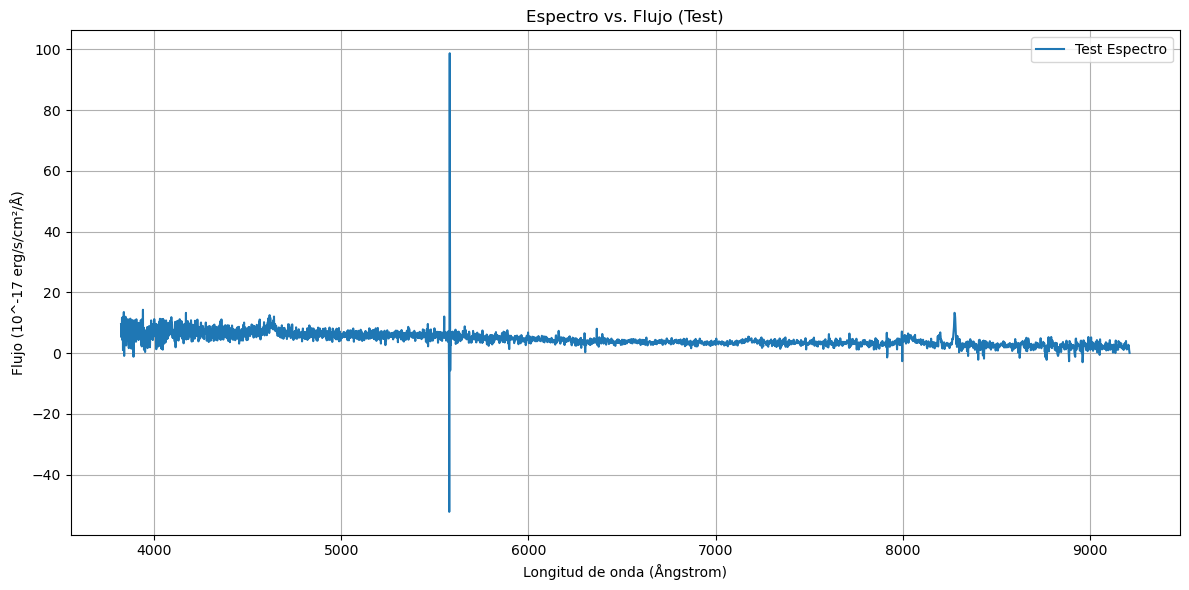

In [ ]:
from astropy.io import fits
import matplotlib.pyplot as plt

file_path = r'spectrums/spec-0266-51630-0003.fits'

with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]  # Asumiendo que Z es un array y queremos el primer valor

test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    wl = list(wavelength)
    fl = list(flux)
    while len(wl) < target_count:
        diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl) - 1)]
        max_idx = np.argmax(diffs)
        new_wl = (wl[max_idx] + wl[max_idx+1]) / 2
        new_fl = (fl[max_idx] + fl[max_idx+1]) / 2
        wl.insert(max_idx+1, new_wl)
        fl.insert(max_idx+1, new_fl)
    return np.array(wl), np.array(fl)

test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# Canal 0: flux; Canal 1: wavelength
input_data = np.stack([test_flux, test_wavelength], axis=0)  # (2, 5000) 2 canales de tamaño 5000
input_data = input_data.reshape(1, 2, num_points)            # (1, 2, 5000) 1 muestra, 2 canales, 5000 puntos/canal

# Normalización
nsamples, nchannels, npoints = input_data.shape # Guardar dimensionalidad inicial
input_flat = input_data.reshape(nsamples, -1) # Aplanar/concatenar (1, 10000)
input_scaled = scaler.transform(input_flat) # Normalizar
input_scaled = input_scaled.reshape(nsamples, nchannels, npoints) # Recuperar dimensionalidad incial

# Convertir a tensor
input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
input_tensor = input_tensor.to(device)

# Evaluar el modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Test Espectro")
plt.xlabel("Longitud de onda (Ångstrom)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro vs. Flujo (Test)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Redshift real: 0.65241706
# Redshift predicho: 0.8086950182914734